In [2]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# =========================
# FILES
# =========================

TRAFFIC_RESULTS_FILE = Path("project_data/simulation_traffic_results.csv")
ROUTE_FILE = Path("project_data/Scheduled_Optimal_Routes.csv")

# =========================
# SETTINGS — MATCH ORIGINAL SIMULATION
# =========================

N_SIMULATIONS = 1000
RANDOM_SEED = 263

SHIFT_TO_SHIFT_SIGMA = 0.25
ROUTE_TO_ROUTE_SIGMA = 0.15
SHIFT_TRAFFIC_MEAN = {
    "8am": 1.10,
    "2pm": 1.05,
}

DEMAND_SIGMA_FRACTION = 0.15

UNLOAD_MINUTES_PER_PALLET = 18.0
TRUCK_COST_PER_HOUR = 220.0
OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_HOUR = 310.0
WET_LEASE_COST_PER_2H_BLOCK = 1400.0


In [3]:
# Load the existing traffic results and scheduled routes
traffic_results = pd.read_csv(TRAFFIC_RESULTS_FILE)
routes = pd.read_csv(ROUTE_FILE)

print(f"Traffic result rows: {len(traffic_results):,}")
print(f"Scheduled routes: {len(routes):,}")
print(f"Day types: {routes['Day'].unique().tolist()}")

print("\nTraffic simulations by day:")
print(traffic_results.groupby("Day")["simulation"].nunique())

assert TRAFFIC_RESULTS_FILE.exists(), f"Missing {TRAFFIC_RESULTS_FILE}"
assert ROUTE_FILE.exists(), f"Missing {ROUTE_FILE}"


Traffic result rows: 2,000
Scheduled routes: 60
Day types: ['Saturday', 'Weekdays']

Traffic simulations by day:
Day
Saturday    1000
Weekdays    1000
Name: simulation, dtype: int64


In [4]:
def route_cost(hours: float) -> float:
    """Cost of one owned route using the same rules as the traffic model."""
    if hours <= OVERTIME_THRESHOLD_HOURS:
        return hours * TRUCK_COST_PER_HOUR

    normal_part = OVERTIME_THRESHOLD_HOURS * TRUCK_COST_PER_HOUR
    overtime_hours = math.ceil(hours - OVERTIME_THRESHOLD_HOURS - 1e-12)
    return normal_part + overtime_hours * OVERTIME_COST_PER_HOUR


In [5]:
def simulate_no_traffic_group(group, n_simulations, rng):
    """
    Reproduce the original demand draws, but remove traffic fluctuations.

    Traffic random draws are still generated and discarded. This is
    intentional: it keeps the RNG sequence aligned with the original
    traffic simulation, meaning the demand for simulation 1, 2, ..., 1000
    is exactly the same as in the traffic simulation.
    """

    group = group.reset_index(drop=True)
    baseline_pallets = group["Demand"].to_numpy(dtype=float)
    baseline_unload_hours = baseline_pallets * UNLOAD_MINUTES_PER_PALLET / 60.0
    baseline_drive_hours = np.maximum(
        0.0,
        group["Duration_hours"].to_numpy() - baseline_unload_hours
    )

    shifts = group["Scheduled_Shift"].to_numpy()
    trucks = group["Truck"].to_numpy()
    n_routes = len(group)

    # Identify trucks used in both shifts, exactly as in the original code.
    truck_shift_rows = {}
    for i, (truck, shift) in enumerate(zip(trucks, shifts)):
        truck_shift_rows.setdefault(truck, {})[shift] = i

    double_shift_trucks = {
        truck: rows
        for truck, rows in truck_shift_rows.items()
        if "8am" in rows and "2pm" in rows
    }

    shift_start_hour = {"8am": 8.0, "2pm": 14.0}
    rows = []

    for sim in range(1, n_simulations + 1):
        # -------------------------
        # SAME DEMAND VARIABILITY
        # -------------------------
        demand_sim = rng.normal(
            baseline_pallets,
            baseline_pallets * DEMAND_SIGMA_FRACTION
        )
        demand_sim = np.clip(np.round(demand_sim), 0, None)
        unload_hours_sim = demand_sim * UNLOAD_MINUTES_PER_PALLET / 60.0

        # -------------------------
        # CONSUME THE SAME TRAFFIC RNG DRAWS
        # -------------------------
        # These draws are deliberately discarded. Their purpose is to keep
        # the demand draws aligned with the existing traffic simulation.
        for shift_name, mean_mult in SHIFT_TRAFFIC_MEAN.items():
            mask = shifts == shift_name
            if not mask.any():
                continue

            rng.lognormal(
                mean=math.log(mean_mult) - 0.5 * SHIFT_TO_SHIFT_SIGMA ** 2,
                sigma=SHIFT_TO_SHIFT_SIGMA
            )

            rng.lognormal(
                mean=-0.5 * ROUTE_TO_ROUTE_SIGMA ** 2,
                sigma=ROUTE_TO_ROUTE_SIGMA,
                size=mask.sum()
            )

        # -------------------------
        # NO TRAFFIC FLUCTUATION
        # -------------------------
        # Traffic multiplier is fixed at 1.0 for every route.
        actual_hours = baseline_drive_hours + unload_hours_sim

        costs = np.array([route_cost(h) for h in actual_hours])

        # Check AM/PM conflicts using the no-traffic route durations.
        # If a conflict occurs, apply the same wet-lease logic as the
        # original model.
        wet_lease_cost = 0.0
        n_conflicts = 0

        for truck, rows_by_shift in double_shift_trucks.items():
            am_idx = rows_by_shift["8am"]
            pm_idx = rows_by_shift["2pm"]

            am_finish_clock = shift_start_hour["8am"] + actual_hours[am_idx]

            if am_finish_clock > shift_start_hour["2pm"]:
                n_conflicts += 1
                costs[pm_idx] = (
                    math.ceil(actual_hours[pm_idx] / 2.0 - 1e-12)
                    * WET_LEASE_COST_PER_2H_BLOCK
                )
                wet_lease_cost += costs[pm_idx]

        total_cost = costs.sum()

        rows.append({
            "simulation": sim,
            "total_hours": actual_hours.sum(),
            "routes_over_3_5h": int((actual_hours > 3.5).sum()),
            "routes_over_4h": int((actual_hours > 4.0).sum()),
            "shift_conflicts": n_conflicts,
            "wet_lease_cost": wet_lease_cost,
            "total_cost": total_cost,
        })

    return pd.DataFrame(rows)


In [6]:
# Generate the no-traffic simulations.
# A fresh RNG with the original seed reproduces the random-number
# sequence used when the traffic simulation was originally generated.

rng = np.random.default_rng(RANDOM_SEED)
no_traffic_results = []

for day_label, group in routes.groupby("Day"):
    print(f"Simulating no-traffic case: {day_label} ({len(group)} routes)...")

    result = simulate_no_traffic_group(
        group,
        N_SIMULATIONS,
        rng
    )

    result["Day"] = day_label
    no_traffic_results.append(result)

no_traffic_results = pd.concat(no_traffic_results, ignore_index=True)

print("\nNo-traffic results generated:")
print(no_traffic_results.head())


Simulating no-traffic case: Saturday (25 routes)...
Simulating no-traffic case: Weekdays (35 routes)...

No-traffic results generated:
   simulation  total_hours  routes_over_3_5h  routes_over_4h  shift_conflicts  \
0           1   104.856244                22               9                1   
1           2    98.856244                15               9                1   
2           3   104.856244                20              11                2   
3           4   104.256244                24              10                0   
4           5   104.556244                18              12                1   

   wet_lease_cost    total_cost       Day  
0          2800.0  27608.127611  Saturday  
1          2800.0  26473.476389  Saturday  
2          5600.0  30561.961778  Saturday  
3             0.0  25410.990111  Saturday  
4          2800.0  28428.641389  Saturday  


In [7]:
# Save the no-traffic results so they can be reused.
NO_TRAFFIC_OUTPUT = Path("project_data/simulation_no_traffic_results.csv")

no_traffic_results.to_csv(NO_TRAFFIC_OUTPUT, index=False)
print(f"Saved: {NO_TRAFFIC_OUTPUT}")


Saved: project_data/simulation_no_traffic_results.csv


In [8]:
# Pair the two datasets by Day + simulation number.
paired = pd.merge(
    traffic_results,
    no_traffic_results,
    on=["Day", "simulation"],
    suffixes=("_Traffic", "_NoTraffic"),
    validate="one_to_one"
)

print(f"Paired observations: {len(paired):,}")
print(paired.groupby("Day")["simulation"].nunique())


Paired observations: 2,000
Day
Saturday    1000
Weekdays    1000
Name: simulation, dtype: int64


In [9]:
# =========================
# PAIRED T-TEST
# =========================

test_results = []

for day_label in paired["Day"].unique():
    day_data = paired[paired["Day"] == day_label]

    traffic_cost = day_data["total_cost_Traffic"]
    no_traffic_cost = day_data["total_cost_NoTraffic"]

    difference = traffic_cost - no_traffic_cost
    t_stat, p_value = ttest_rel(traffic_cost, no_traffic_cost)

    test_results.append({
        "Day": day_label,
        "N": len(day_data),
        "Mean Cost - Traffic": traffic_cost.mean(),
        "Mean Cost - No Traffic": no_traffic_cost.mean(),
        "Mean Difference": difference.mean(),
        "Mean % Increase": difference.mean() / no_traffic_cost.mean() * 100,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Significant (α = 0.05)": p_value < 0.05,
    })

test_results = pd.DataFrame(test_results)
test_results


,Day,N,Mean Cost - Traffic,Mean Cost - No Traffic,Mean Difference,Mean % Increase,t-statistic,p-value,Significant (α = 0.05)
0,Saturday,1000,28755.458877,26883.234785,1872.224092,6.964281,13.555623,1.499958e-38,True
1,Weekdays,1000,55304.790144,51981.364526,3323.425618,6.393494,12.564185,1.014576e-33,True


In [10]:
# =========================
# OVERALL PAIRED T-TEST
# =========================

traffic_cost = paired["total_cost_Traffic"]
no_traffic_cost = paired["total_cost_NoTraffic"]
difference = traffic_cost - no_traffic_cost

t_stat, p_value = ttest_rel(
    traffic_cost,
    no_traffic_cost
)

overall_results = pd.DataFrame({
    "Metric": [
        "Mean Traffic Cost",
        "Mean No-Traffic Cost",
        "Mean Difference",
        "Mean % Increase",
        "t-statistic",
        "p-value",
        "Significant (α = 0.05)",
    ],
    "Value": [
        traffic_cost.mean(),
        no_traffic_cost.mean(),
        difference.mean(),
        difference.mean() / no_traffic_cost.mean() * 100,
        t_stat,
        p_value,
        p_value < 0.05,
    ]
})

overall_results


,Metric,Value
0,Mean Traffic Cost,42030.124511
1,Mean No-Traffic Cost,39432.299656
2,Mean Difference,2597.824855
3,Mean % Increase,6.588063
4,t-statistic,17.313723
5,p-value,0.0
6,Significant (α = 0.05),True


In [11]:
# =========================
# SUMMARY OF THE PAIRED DIFFERENCES
# =========================

difference_summary = pd.DataFrame({
    "Statistic": [
        "Mean difference",
        "Median difference",
        "Standard deviation",
        "Minimum difference",
        "Maximum difference",
        "95th percentile difference",
        "Proportion where traffic costs more",
    ],
    "Value": [
        difference.mean(),
        difference.median(),
        difference.std(),
        difference.min(),
        difference.max(),
        difference.quantile(0.95),
        (difference > 0).mean(),
    ]
})

difference_summary


,Statistic,Value
0,Mean difference,2597.824855
1,Median difference,1179.184143
2,Standard deviation,6710.183446
3,Minimum difference,-17462.196465
4,Maximum difference,41035.794556
5,95th percentile difference,15315.980268
6,Proportion where traffic costs more,0.614500


In [12]:
# Optional: save the paired observations and test results.
paired.to_csv("project_data/paired_traffic_no_traffic_results.csv", index=False)
test_results.to_csv("project_data/paired_t_test_by_day.csv", index=False)
overall_results.to_csv("project_data/paired_t_test_overall.csv", index=False)

print("Saved:")
print(" - project_data/simulation_no_traffic_results.csv")
print(" - project_data/paired_traffic_no_traffic_results.csv")
print(" - project_data/paired_t_test_by_day.csv")
print(" - project_data/paired_t_test_overall.csv")


Saved:
 - project_data/simulation_no_traffic_results.csv
 - project_data/paired_traffic_no_traffic_results.csv
 - project_data/paired_t_test_by_day.csv
 - project_data/paired_t_test_overall.csv


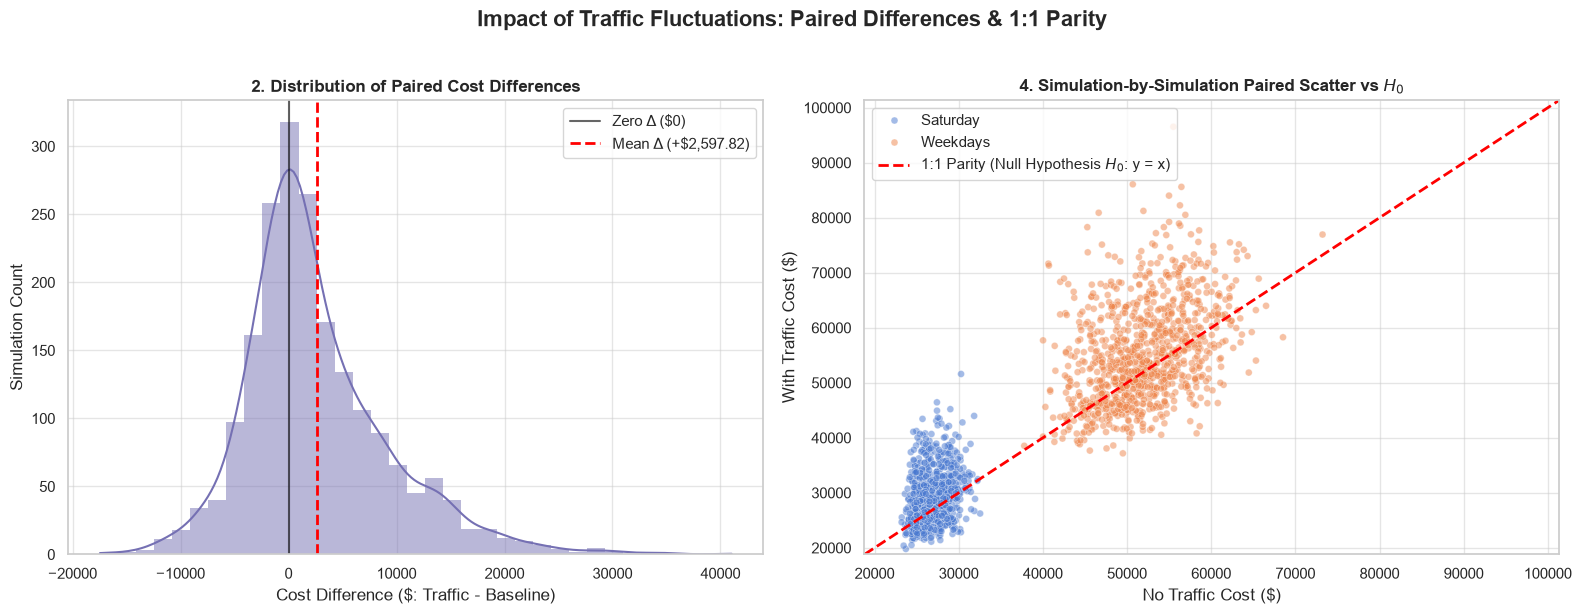

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Impact of Traffic Fluctuations: Paired Differences & 1:1 Parity",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

# -------------------------------------------------------------------------
# Subplot 2: Paired Differences (Traffic - No Traffic)
# -------------------------------------------------------------------------
sns.histplot(
    difference, ax=axes[0], kde=True, color="#7570b3", bins=35, edgecolor="none"
)
axes[0].axvline(0, color="black", linestyle="-", alpha=0.6, label="Zero \u0394 ($0)")
axes[0].axvline(
    difference.mean(), color="red", linestyle="--", linewidth=2,
    label=f"Mean \u0394 (+${difference.mean():,.2f})"
)
axes[0].set_title("2. Distribution of Paired Cost Differences", fontweight="bold")
axes[0].set_xlabel("Cost Difference ($: Traffic - Baseline)")
axes[0].set_ylabel("Simulation Count")
axes[0].legend(loc="upper right")

# -------------------------------------------------------------------------
# Subplot 4: Pairwise Simulation Scatter (1:1 Parity Line / H0)
# -------------------------------------------------------------------------
sns.scatterplot(
    data=paired, x="total_cost_NoTraffic", y="total_cost_Traffic",
    hue="Day", alpha=0.5, s=25, ax=axes[1]
)

# Calculate dynamic axis bounds to plot clean 1:1 line
min_val = min(paired["total_cost_NoTraffic"].min(), paired["total_cost_Traffic"].min()) * 0.95
max_val = max(paired["total_cost_NoTraffic"].max(), paired["total_cost_Traffic"].max()) * 1.05

axes[1].plot(
    [min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2,
    label="1:1 Parity (Null Hypothesis $H_0$: y = x)"
)
axes[1].set_xlim(min_val, max_val)
axes[1].set_ylim(min_val, max_val)
axes[1].set_title("4. Simulation-by-Simulation Paired Scatter vs $H_0$", fontweight="bold")
axes[1].set_xlabel("No Traffic Cost ($)")
axes[1].set_ylabel("With Traffic Cost ($)")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

The null hypothesis is that the mean simulated cost is the same with and without traffic fluctuations.

- **p < 0.05:** reject H₀; traffic fluctuations have a statistically significant effect on cost.
- **p ≥ 0.05:** fail to reject H₀; there is insufficient evidence that traffic fluctuations change mean cost.